# Phase 7 Analysis Notebook

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

SEGMENTATION_DIR = (
    PROJECT_ROOT
    / "metadata"
    / "segmentation"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "segmentation"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

In [17]:
windows = pd.read_csv(
    SEGMENTATION_DIR
    / "chbmit_window_manifest.csv"
)

recording_summary = pd.read_csv(
    SEGMENTATION_DIR
    / "chbmit_recording_window_summary.csv"
)

case_summary = pd.read_csv(
    SEGMENTATION_DIR
    / "chbmit_case_window_summary.csv"
)

seizure_coverage = pd.read_csv(
    SEGMENTATION_DIR
    / "chbmit_seizure_window_coverage.csv"
)

print("Windows:", len(windows))
print(
    "Recordings:",
    windows["recording_id"].nunique(),
)
print(
    "Cases:",
    windows["case_id"].nunique(),
)
print(
    windows["label_name"].value_counts()
)

Windows: 1624301
Recordings: 654
Cases: 23
label_name
non_ictal    1618605
ictal           5696
Name: count, dtype: int64


# Label distribution

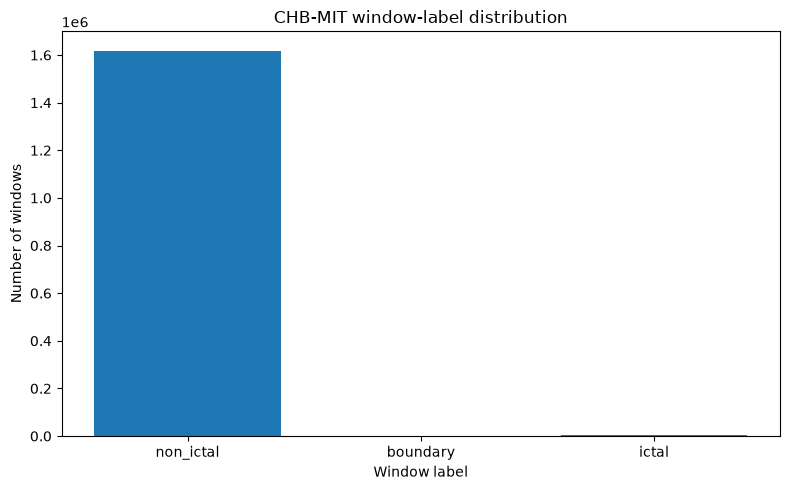

In [18]:
label_counts = (
    windows["label_name"]
    .value_counts()
    .reindex(
        [
            "non_ictal",
            "boundary",
            "ictal",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    label_counts.index,
    label_counts.values,
)

ax.set_xlabel("Window label")
ax.set_ylabel("Number of windows")
ax.set_title(
    "CHB-MIT window-label distribution"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "windows_per_label.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

Due to the extreme imbalance, a log scale chart is also useful:

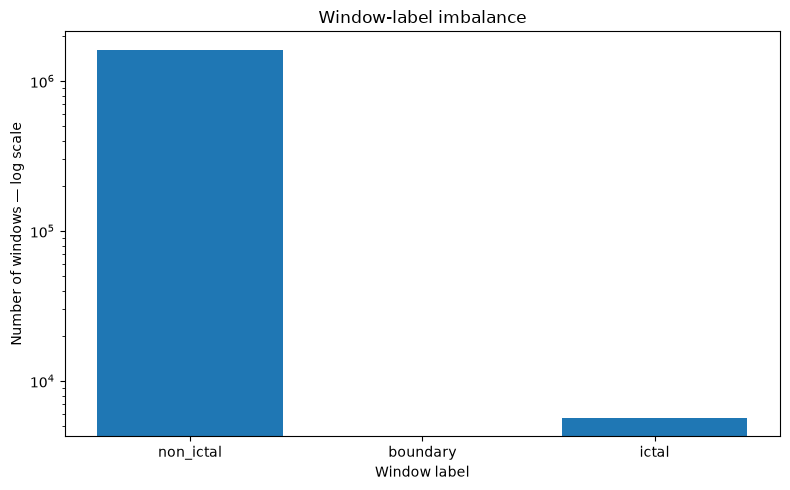

In [19]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    label_counts.index,
    label_counts.values,
)

ax.set_yscale("log")
ax.set_xlabel("Window label")
ax.set_ylabel(
    "Number of windows — log scale"
)
ax.set_title(
    "Window-label imbalance"
)

fig.tight_layout()
plt.show()

# Windows of each Case

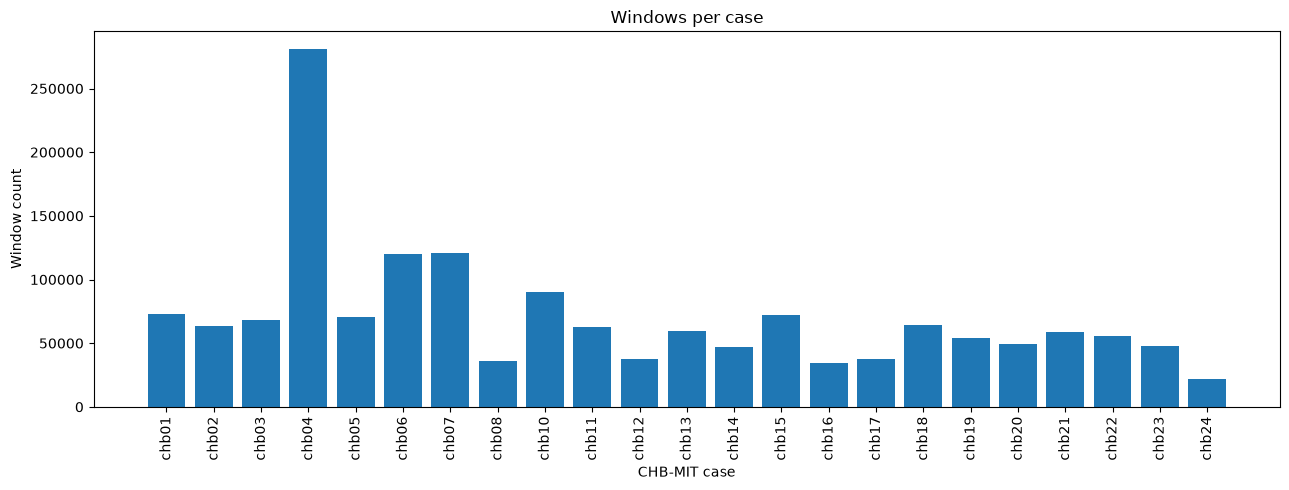

In [20]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.bar(
    case_summary["case_id"],
    case_summary[
        "total_window_count"
    ],
)

ax.set_xlabel("CHB-MIT case")
ax.set_ylabel("Window count")
ax.set_title("Windows per case")
ax.tick_params(
    axis="x",
    rotation=90,
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "windows_per_case.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Ictal Windows for Each Case

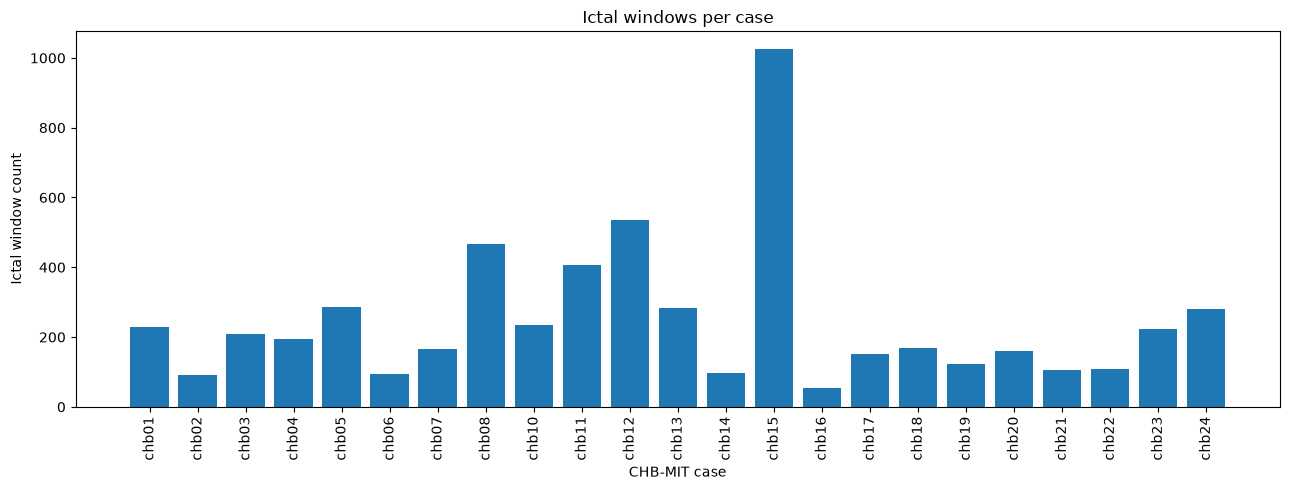

In [21]:
fig, ax = plt.subplots(
    figsize=(13, 5)
)

ax.bar(
    case_summary["case_id"],
    case_summary[
        "ictal_window_count"
    ],
)

ax.set_xlabel("CHB-MIT case")
ax.set_ylabel("Ictal window count")
ax.set_title(
    "Ictal windows per case"
)
ax.tick_params(
    axis="x",
    rotation=90,
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "ictal_windows_per_case.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Overlap Fraction Distribution

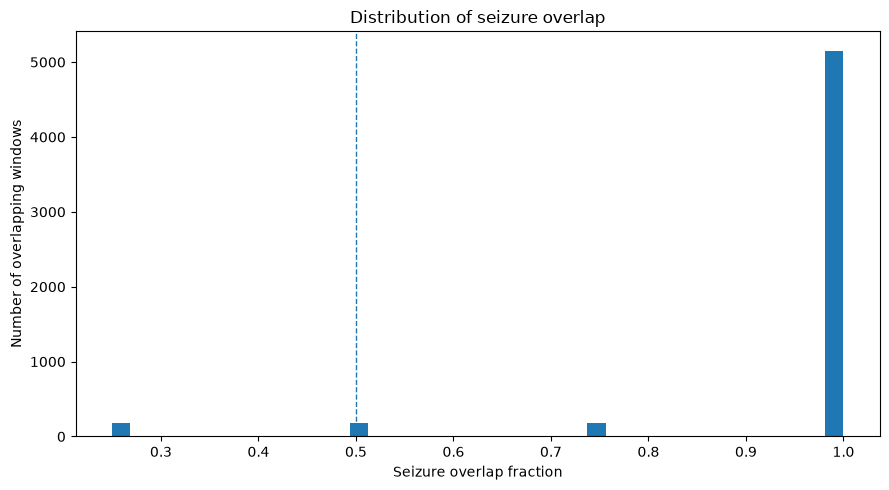

In [22]:
overlapping_windows = windows.loc[
    windows["overlaps_seizure"]
]

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.hist(
    overlapping_windows[
        "seizure_overlap_fraction"
    ],
    bins=40,
)

ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "Seizure overlap fraction"
)
ax.set_ylabel(
    "Number of overlapping windows"
)
ax.set_title(
    "Distribution of seizure overlap"
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "overlap_fraction_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [23]:
selected = windows.loc[
    windows["label_name"]
    == "ictal"
].iloc[0]

selected[
    [
        "case_id",
        "recording_id",
        "start_seconds",
        "end_seconds",
        "seizure_overlap_seconds",
        "seizure_overlap_fraction",
    ]
]

case_id                        chb01
recording_id                chb01_03
start_seconds                 2994.0
end_seconds                   2998.0
seizure_overlap_seconds          2.0
seizure_overlap_fraction         0.5
Name: 5095, dtype: object

In [24]:
raw = mne.io.read_raw_fif(
    PROJECT_ROOT
    / selected["output_fif_path"],
    preload=False,
    verbose="ERROR",
)

raw.plot(
    start=max(
        0,
        float(selected["start_seconds"])
        - 4
    ),
    duration=12,
    n_channels=17,
    scalings="auto",
)

# Manual Window Ictal Control

In [28]:
import os
import sys
from pathlib import Path

# Find the path to the main project folder and add it to Python
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [25]:
selected = windows.loc[
    windows["label_name"] == "ictal"
].sort_values(
    "seizure_overlap_fraction",
    ascending=False,
).iloc[0]

In [29]:
from src.segmentation.loader import (
    load_window_from_manifest_row,
)

data, channel_names, sfreq = (
    load_window_from_manifest_row(
        row=selected,
        project_root=PROJECT_ROOT,
    )
)

print(data.shape)
print(channel_names)
print(sfreq)

(17, 1024)
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FZ-CZ', 'CZ-PZ', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'P8-O2']
256.0


# Class Imbalance Review

In [30]:
binary_windows = windows.loc[
    windows["binary_label"].notna()
].copy()

binary_distribution = (
    binary_windows["binary_label"]
    .value_counts()
    .sort_index()
)

binary_distribution

binary_label
0    1618605
1       5696
Name: count, dtype: int64

Ratio:

In [31]:
binary_windows = windows.loc[
    windows["binary_label"].notna()
].copy()

binary_distribution = (
    binary_windows["binary_label"]
    .value_counts()
    .sort_index()
)

binary_distribution

binary_label
0    1618605
1       5696
Name: count, dtype: int64